# The Normal Distribution

In this notebook we are going to cover random variables, the univariate and multivariate normal distributions (giving visualizations with the bivariate normal distribution), as well as marginal and conditional distributions. These concepts are crucial for understanding Gaussian Process Regression (GPR), which will be covered in another notebook.

## Random Variables

A [random variable](http://www.stat.yale.edu/Courses/1997-98/101/ranvar.htm), usually denoted by a capital letter (such as $X$), is a variable whose possible values are numerical outcomes of a random phenomenon. There are two types of random variables: discrete and continuous.

### Discrete Random Variables

A random variable whose outputs are countable is called a discrete random variable. An example of a discrete variable is the value assigned to the outcome of flipping a coin or rolling a die.

$$
X=
\begin{cases}
  0, & \text{if}\ heads\\
  1, & \text{if}\ tails
\end{cases}
$$

In the coin case, there are only two possible outcomes: either heads or tails. If the outcome of flipping the coin is heads, $X$ has the value 0, and if the outcome was tails, then $X$ has the value 1. There are no other possible values for $X$, so $X$ is a discrete random variable. A discrete random variable can be described by a [probability mass function](https://en.wikipedia.org/wiki/Random_variable#Standard_case) that assigns an exact probability to each value that a random variable can have.

### Continuous Random Variables

If a random variable is not countable, then it is a continuous random variable. Therefore its distribution can be descried through a [probability density function (pdf)](https://en.wikipedia.org/wiki/Probability_density_function). Data such as heights, weights, and temperatures are continuous variables. Unlike discrete variables, continuous variables cannot be measured exactly (there is always some limit to the decimal places and rounding of numbers going on), so a pdf must be used to describe a continuous variable. 


## The Central Limit Theorem

Essentially what the central limit states is that if you take $i$ number of samples from a population, with each sample consisting of $n$ number of independent random variables such as $X_1,X_2,\ldots,X_n$, then the $i$ number of sample means will approximate a normal distribution. This holds true even if the population does *not* have a normal distribution itself. The more samples are taken  (with a sufficiently large $n$), the better the sample means approximate a standard normal distribution. As $i$ goes to infinity, the exact standard normal distribution is obtained, written as 

$$
\mathcal{N}(0,1) = \left(\frac{\bar {X_i} - \mu}{\sigma/\sqrt i}\right) \quad \textrm{as} \quad i \rightarrow \infty
$$

where $\mu$ is the population mean, and $\sigma$ is the population standard deviation.
I will not go into more details about the Central Limit Theorem (as I have a lot to learn about it myself), but this summary still brings out the importance of the normal distribution and why it is so commonly observed.

## The Univariate Normal Distribution

The [normal distribution](https://en.wikipedia.org/wiki/Normal_distribution) is a type of continuous normal distribution.  
The univariate normal distribution can express the probability distribution of **one** random variable, with a probability density function

$$
f(x) = \frac{1}{\sigma\sqrt{2\pi}}\exp{-\frac{1}{2}\left(\frac{X-\mu}{\sigma}\right)}^2
$$

where $\mu$ is the mean (expected) value of the distribution, and $\sigma$ is the standard deviation.

A random variable with a normal distribution would be denoted as

$$
X \sim \mathcal{N} \left( \mu, \sigma^2 \right)
$$

where $\sigma^2$ (square of the standard deviation) is the variance.

A *standard* normal univariate distribution where $\mu$ is 0 and $\sigma^2$ is 1 is denoted as 

$$
X \sim \mathcal{N} \left( 0, 1\right)
$$


Below is a demonstration of what a normal distribution, sometimes called a bell curve, looks like. Note how changing the mean and standard deviation modifies the curves.

In [1]:
# imports
import numpy as np
import matplotlib 
import matplotlib.pyplot as plt

<IPython.core.display.Javascript object>


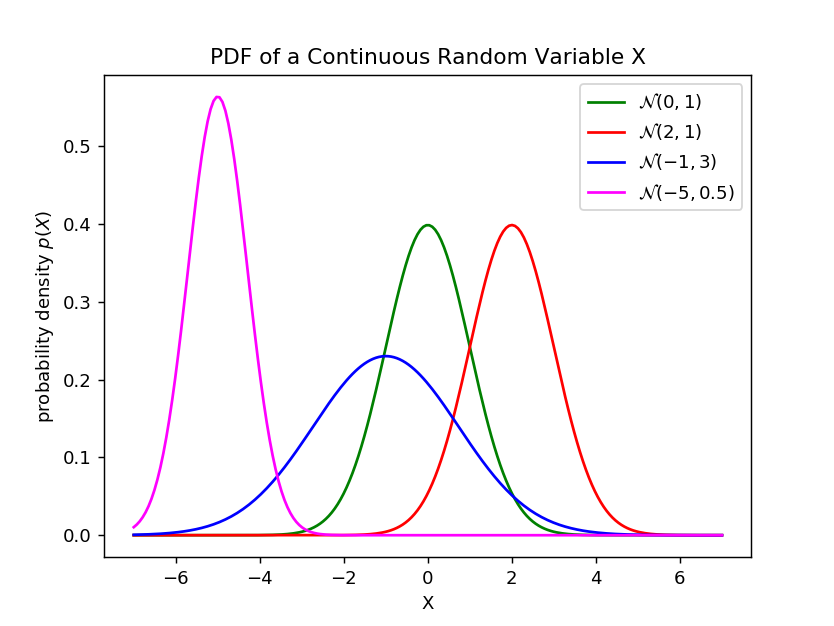

In [2]:
%matplotlib notebook

def normal_distribution(x, mean, variance):
    return ((1 / np.sqrt(2 * np.pi * variance)) * 
            np.exp(-(x - mean)**2 / (2 * variance)))

n = 200
points = np.linspace(-7,7, n)
plt.plot(points, normal_distribution(points, 0, 1), label="$\mathcal{N}(0, 1)$", color="green")
plt.plot(points, normal_distribution(points, 2, 1), label="$\mathcal{N}(2, 1)$", color="red")
plt.plot(points, normal_distribution(points, -1, 3), label="$\mathcal{N}(-1, 3)$", color="blue")
plt.plot(points, normal_distribution(points, -5, 0.5), label="$\mathcal{N}(-5, 0.5)$", color="magenta")

plt.xlabel("X")
plt.ylabel("probability density $p(X)$")
plt.title("PDF of a Continuous Random Variable X")
plt.legend()

plt.show()

The standard normal distribution is shown in green in the figure above. The figure also shows how changing the mean or variance affects the probability density function. Changing the mean value shifts the curve left or right. Changing the variance affects the width of the distribution.

## The Multivariate Normal Distribution

The multivariate normal distribution, also called a joint normal distribution, is an extension of the univariate one to higher dimensions in which the probability distribution of more than one random variable is expressed. These variables can be independent or dependent as we will see later.

The probability density distribution in this case becomes
$$
f_{\mathbf {X}} (X_1, X_2, \ldots, X_n) = \frac{1}{\sqrt{(2\pi)^n|\Sigma|}}
\exp\left({-\frac{1}{2}\left(\mathbf{X} - \mathbf \mu\right)^T \Sigma ^{-1} \left(\mathbf{X} - \mathbf \mu\right)}\right)
$$

where $X$ is an n-dimensional normal random vector consisting of random variables $X_1 \ldots X_n$, $\mathbf \mu$ is the mean vector of the multivariate normal distribution, and $\Sigma$ is the [covariance matrix](https://en.wikipedia.org/wiki/Covariance_matrix).

A [normal random vector](https://en.wikipedia.org/wiki/Multivariate_normal_distribution#Normal_random_vector) $\mathbf X$ has a multivariate distribution written as 

$$
\mathbf X \sim \mathcal{N} \left(\mathbf \mu, \Sigma \right)
$$

where again $\mathbf \mu$ is the mean vector of the distribution and $\Sigma$ is the covariance matrix.

This is also sometimes written as 

$$
\mathbf X \sim \mathcal{N} \left(\begin{bmatrix} \mathbb E X_1 \\ \mathbb E {X_2} \\ \vdots \\ \mathbb E {X_n} \end{bmatrix}, \Sigma \right)
$$

where $\mathbb E$ stands for the expected value.

Let's go over what the covariance matrix now before continuing with the multivariate distribution.



## The Covariance Matrix

The [covariance matrix](https://en.wikipedia.org/wiki/Covariance_matrix) is a [symmetric](https://en.wikipedia.org/wiki/Symmetric_matrix) [positive-definite matrix](https://en.wikipedia.org/wiki/Definiteness_of_a_matrix#Negative-definite,_semidefinite_and_indefinite_matrices) which shows the covariance between each pair of elements in a random vector.

So if we have a random vector $\mathbf X$ such that 

$$
X = \begin{bmatrix}  X_1 \\  X_2 \\ \vdots \\  X_n \end{bmatrix} 
$$

then the covariance matrix is expressed as 


$$
\Sigma = \begin{bmatrix} var(X_1, X_1) & \ldots & cov(X_1, X_n) \\
\vdots & \ddots & \vdots \\
cov(X_n, X_1) & \ldots & var(X_n, X_n) \end{bmatrix}
$$

Notice that the diagonal elements are variance instead of covariance because the covariance between a random variable and itself is the variance. The covariance between two values expresses how related the variables are. A high covariance means the variables are strongly related, and a low covariance means the variables are weakly related. When covariance is 0, it means the two variables are [independent](https://en.wikipedia.org/wiki/Independence_(probability_theory)) , meaning the occurrence of one does not affect the probability of the other in any way. **Note**: Covariance between $X_a$ and $X_b$ is the same as covariance between $X_b$ and $X_a$, so the matrix is symmetric as mentioned previously.


### The Bivariate Normal Distribution

Now that we covered the essentials of the multivariate normal distribution, let's see what is looks like. For this we will use the bivariate normal distribution which is the simplest form of a multivariate normal distribution.

A random vector $\mathbf X$ that comes from a bivariate normal distribution is then expressed as
$$
\mathbf X = \begin{bmatrix}
{X_1} \\ {X_2} 
\end{bmatrix} \sim \mathcal{N}
\left(
\begin{bmatrix} \mathbb E X_1 \\ \mathbb E {X_2} \end{bmatrix}, 
\begin{bmatrix} var(X_1, X_1) & cov(X_1, X_2) \\
cov(X_2, X_1)& var(X_2, X_2) \end{bmatrix}
\right )
$$


Lets first visualize the standard normal multivariate distribution, where the mean vector is $\mathbf 0$ and the two variables $X_1$ and $X_2$ are independent of each other (i.e. their covariance is 0).

$$\begin{bmatrix}
X_1 \\ X_2
\end{bmatrix} \sim \mathcal{N} \left (\begin{bmatrix} 0 \\ 0 \end{bmatrix}, \begin{bmatrix} 1 && 0 \\ 0 && 1 \end{bmatrix} \right)
$$

<IPython.core.display.Javascript object>


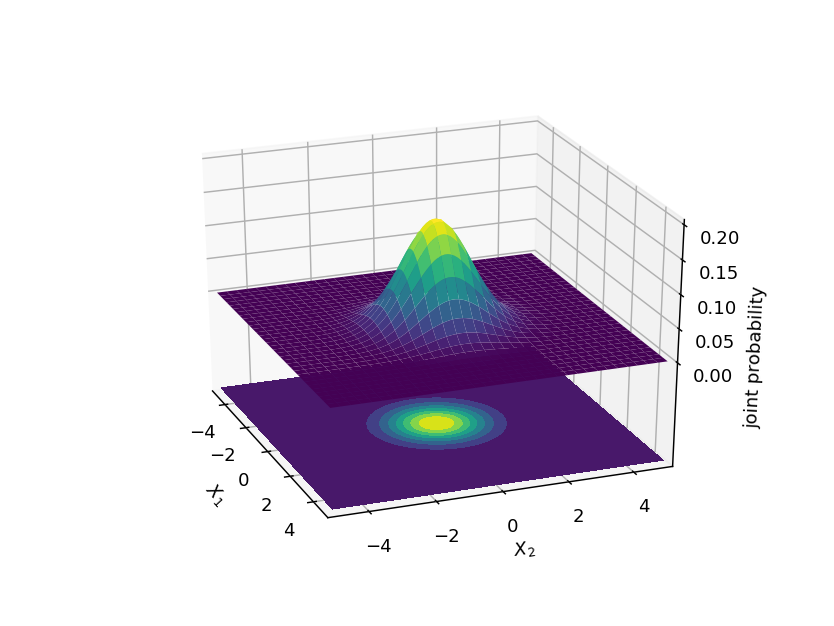

In [3]:
# code modified from https://scipython.com/blog/visualizing-the-bivariate-gaussian-distribution/


from matplotlib import cm
from mpl_toolkits.mplot3d import Axes3D

# Our 2-dimensional distribution will be over variables X1 and X2
N = 100
X1 = np.linspace(-5, 5, N)
X2 = np.linspace(-5, 5, N)
X1, X2 = np.meshgrid(X1, X2)

# Mean vector and covariance matrix
mu = np.array([0., 0.])
Sigma = np.array([[ 1. , -0.], [0.,  1.]])

# Pack X1 and X2 into a single 3-dimensional array
pos = np.empty(X1.shape + (2,))
pos[:, :, 0] = X1
pos[:, :, 1] = X2

def multivariate_gaussian(pos, mu, Sigma):
    """Return the multivariate Gaussian distribution on array pos.

    pos is an array constructed by packing the meshed arrays of variables
    x_1, x_2, x_3, ..., x_k into its _last_ dimension.

    """

    n = mu.shape[0]
    Sigma_det = np.linalg.det(Sigma)
    Sigma_inv = np.linalg.inv(Sigma)
    N = np.sqrt((2*np.pi)**n * Sigma_det)
    # This einsum call calculates (x-mu)T.Sigma-1.(x-mu) in a vectorized
    # way across all the input variables.
    fac = np.einsum('...k,kl,...l->...', pos-mu, Sigma_inv, pos-mu)

    return np.exp(-fac / 2) / N

# The distribution on the variables X1, X2 packed into pos.
Z = multivariate_gaussian(pos, mu, Sigma)

# Create a surface plot and projected filled contour plot under it.
fig = plt.figure()
ax = fig.gca(projection='3d')
ax.plot_surface(X1, X2, Z, rstride=3, cstride=3, linewidth=1, antialiased=True,
                cmap=cm.viridis)

cset = ax.contourf(X1, X2, Z, zdir='z', offset=-0.15, cmap=cm.viridis)

# Adjust the limits, ticks and view angle
ax.set_xlim(-5,5)
ax.set_ylim(-5,5)
ax.set_zlim(-0.15,0.2)
ax.set_xlabel('$X_1$')
ax.set_ylabel('$X_2$')
ax.set_zlabel('joint probability')
ax.set_zticks(np.linspace(0,0.2,5))
ax.view_init(27, -21)

plt.show()

This is what the standard normal bivariate distribution looks like. There is no covariance between random variables $X_1$ and $X_2$ so the contour plot on the bottom of the distribution looks like a circle. Below is an example if we modify the covariance matrix to have non-zero covariance between $X_1$ and $X_2$.

<IPython.core.display.Javascript object>


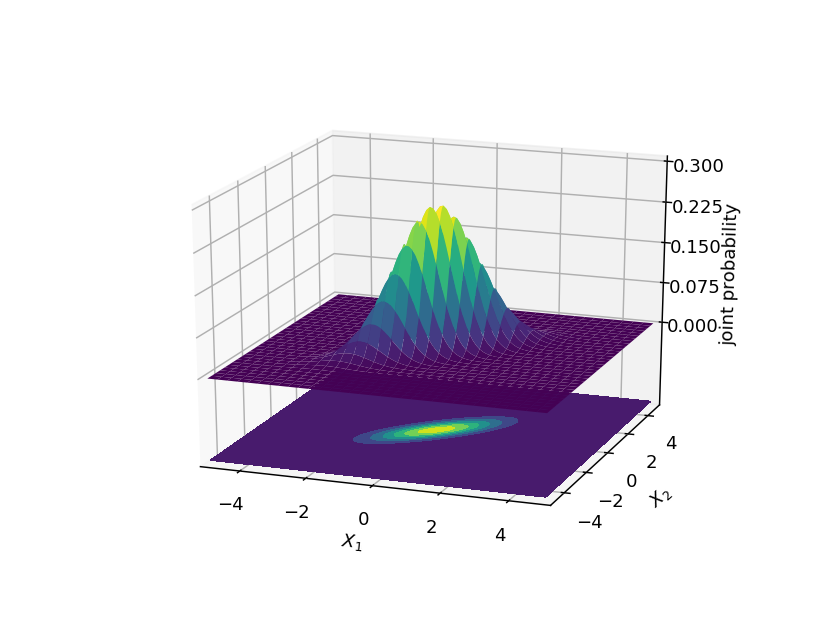

In [4]:
# code modified from https://scipython.com/blog/visualizing-the-bivariate-gaussian-distribution/

mu = np.array([0., 0.]) # same mean as above distribution
Sigma = np.array([[ 1. , 0.8], [0.8,  1.]]) # 0.8 covariance between X1 and X2
# The distribution on the variables X, Y packed into pos.
Z = multivariate_gaussian(pos, mu, Sigma)

# Create a surface plot and projected filled contour plot under it.
fig = plt.figure()
ax = fig.gca(projection='3d')
ax.plot_surface(X1, X2, Z, rstride=3, cstride=3, linewidth=1, antialiased=True,
                cmap=cm.viridis)

cset = ax.contourf(X1, X2, Z, zdir='z', offset=-0.15, cmap=cm.viridis)

# Adjust the limits, ticks and view angle
ax.set_xlim(-5,5)
ax.set_ylim(-5,5)
ax.set_zlim(-0.15,0.3)
ax.set_xlabel('$X_1$')
ax.set_ylabel('$X_2$')
ax.set_zlabel('joint probability')
ax.set_zticks(np.linspace(0,0.3,5))
ax.view_init(20, -70)

plt.show()

The 3D plot looks squished now, and the contour plot on the bottom now looks ellipsoidal. In this case, the covariance between the variables is positive so as the value of one variable increases, the value of the other also increases.

## The Marginal Distribution

The [marginal distribution](https://en.wikipedia.org/wiki/Marginal_distribution) is a normal (possibly multivariate) distribution that is a subset of another multivariate distribution. If we have an original distribution such as

$$
\mathbf X = \begin{bmatrix}
{X_1} \\ {X_2} \\ {X_3}
\end{bmatrix} \sim \mathcal{N}
\left(
\begin{bmatrix} \mathbb E X_1 \\ \mathbb E {X_2} \\ \mathbb E {X_3} \end{bmatrix}, 
\begin{bmatrix} var(X_1, X_1) & cov(X_1, X_2) & cov(X_1, X_3) \\
cov(X_2, X_1) & var(X_2, X_2) & cov(X_2, X_3) \\
cov(X_3, X_1) & cov(X_3, X_2) & var(X_3, X_3) \end{bmatrix}
\right )
$$

we can make a marginal distribution like this one 

$$
\mathbf X = \begin{bmatrix}
{X_1} \\ {X_3}
\end{bmatrix} \sim \mathcal{N}
\left(
\begin{bmatrix} \mathbb E X_1 \\ \mathbb E {X_3} \end{bmatrix}, 
\begin{bmatrix} var(X_1, X_1)& cov(X_1, X_3) \\
cov(X_3, X_1) & var(X_3, X_3) \end{bmatrix}
\right )
$$

The variables that are removed (in this case $X_2$) are said to be marginalized out.


 In the case we start with a bivariate distribution, taking a marginal distribution yields a univariate distribution of the random variables. Let's look at this visually.

<IPython.core.display.Javascript object>


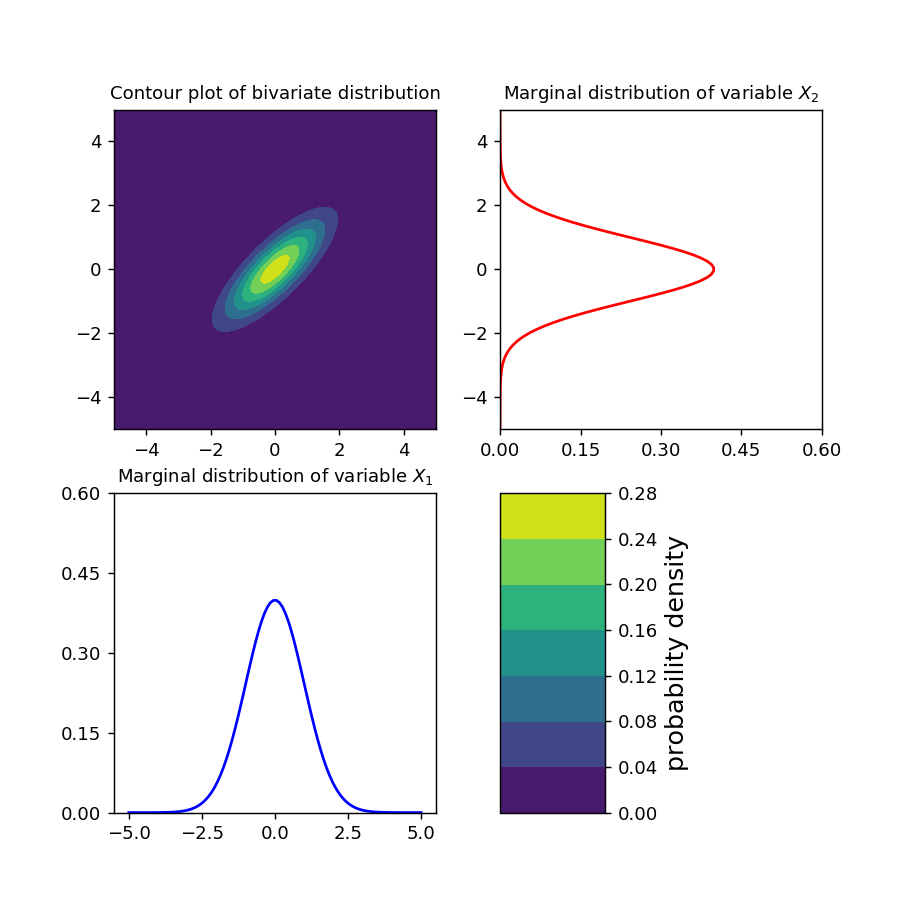

In [5]:
#adapted from https://peterroelants.github.io/posts/multivariate-normal-primer/

from mpl_toolkits.axes_grid1 import make_axes_locatable


X1_lin = np.linspace(-5, 5, N) # set these so I dont have to reassign X1 and X2 from before
X2_lin = np.linspace(-5, 5, N)

fig,axes = plt.subplots(2, 2, figsize=(7, 7))

#axs[0,0]
cp = axes[0,0].contourf(X2_lin, X1_lin, Z)
axes[0,0].set_xlim(-5,5)
axes[0,0].set_ylim(-5,5)
axes[0,0].set_title("Contour plot of bivariate distribution", fontsize=10)

#axs[0,1]
p1 = normal_distribution(X2_lin, mu[1], Sigma[1,1])
axes[0,1].plot(p1, X2_lin, color="red")
axes[0,1].set_xticks(np.linspace(0,0.6,5))
axes[0,1].set_xlim(0, 0.6)
axes[0,1].set_ylim(-5, 5)
axes[0,1].set_title("Marginal distribution of variable $X_2$", fontsize=10)

#axs[1,0] 
p = normal_distribution(X1_lin, mu[0], Sigma[0,0]) 
axes[1,0].plot(X1_lin, p, color="blue")
axes[1,0].set_ylim(-5, 5)
axes[1,0].set_ylim(0, 0.6)
axes[1,0].set_yticks(np.linspace(0,0.6,5))
axes[1,0].set_title("Marginal distribution of variable $X_1$", fontsize=10)


#axs[1,1]
axes[1,1].set_visible(False)
divider = make_axes_locatable(axes[1,1])
cax = divider.append_axes('left', size='50%', pad=0.05)
cbar = fig.colorbar(cp, cax=cax)
cbar.ax.set_ylabel('probability density', fontsize=14)

plt.show()

As you can see, the marginal distribution of a bivariate distribution is a univariate distribution. In this case, the two variables had the same mean (same expected values in the mean vector) and the same variance (same values along the diagonal of the covariance matrix), therefore the two marginal univariate distributions look identical. That might not be the case every time. Change the $\mu$ vector and covariance matrix values in the previous cell that produced the narrow bivariate distribution and rerun both cells to see the changes. You should see a similar translation or widening of the distribution like we saw in the univariate distribution in the beginning of the notebook.

## The Conditional Distribution

The conditional distribution is written as 

$$
p(X_1|X_2) \sim \mathcal{N}\left(\mu_{X_1|X_2},\Sigma_{X_1|X_2}\right)
$$

It expresses the distribution of $X_1$ **given** $X_2$. Think of the conditional distribution as cutting through the original multivariate distribution which forms another normal (univariate) distribution as the conditional distribution. 


A general joint normal distribution of two **sub-vectors** $\mathbf{X_1}$ and $\mathbf{X_2}$ from a $n$-dimensional vector $\mathbf X$  can be written as

$$
\mathbf X = \begin{bmatrix}
\mathbf {X_1} \\ \mathbf{X_2} 
\end{bmatrix} \sim \mathcal{N}
\left(
\begin{bmatrix} \mathbb E \mathbf{X_1} \\ \mathbb E \mathbf{X_2} \end{bmatrix}, 
\begin{bmatrix} \Sigma_{11} & \Sigma_{12} \\
\Sigma_{21} & \Sigma_{22} \end{bmatrix}
\right )
$$

where $\Sigma_{11}$ is a sub-matrix containing covariance between pairs of entries in vector $\mathbf{X_1}$ and $\Sigma_{22}$ is a sub-matrix containing covariance between entries in vector $\mathbf{X_2}$. The covariance between entries vectors $\mathbf{X_1}$ and $\mathbf{X_2}$ is contained in sub-matrix $\Sigma_{12}$. $\Sigma_{21}$ contains the covariances between entries in vectors $\mathbf{X_2}$ and $\mathbf{X_1}$. This is an extension to when $\mathbf{X_1}$ and $\mathbf{X_2}$ are one-dimensional (like we have discussed so far in the bivariate normal distribution).



The conditional mean and covariance matrices of $\mathbf{X_1} |\mathbf{X_2}$ and $\mathbf{X_2} |\mathbf{X_1}$ can be calculated as

$$ \begin{align*}
\mu_{X_1|X_2} &= \mathbf {\mu_{X_1}}+ \Sigma_{12}\Sigma_{22}^{-1}\left(\mathbf {X_2} - \mathbf{\mu_{X_2}}\right) \\
\Sigma_{X_1|X_2} &= \Sigma_{11} - \Sigma_{12}\Sigma_{22}^{-1}\Sigma_{21}\\
\mu_{X_2|X_1} &= \mathbf {\mu_{X_2}}+ \Sigma_{21}\Sigma_{11}^{-1}\left(\mathbf {X_1} - \mathbf{\mu_{X_1}}\right) \\
\Sigma_{X_2|X_1} &= \Sigma_{22} - \Sigma_{21}\Sigma_{11}^{-1}\Sigma_{12}
\end{align*}
$$

Let's look at a conditional distribution taken from the bivariate distribution. There $\mathbf X$ is a 2-dimensional vector, thus $\mathbf{X_1}$ and $\mathbf{X_2}$ are one-dimensional sub-vectors (i.e. scalar values). Again, the same principles can be applied even if $\mathbf{X_1}$ and $\mathbf{X_2}$ are **not** one-dimensional. We are using the bivariate distribution as it can be visualized.

In [6]:
# code modified from https://peterroelants.github.io/posts/multivariate-normal-primer/

# we are still using mean and covariance matrix defined previously
# Get the mean values from the vector 
mean_X1 = mu[0]
mean_X2 = mu[1]

# Get the blocks (single values in bivariate case) from the covariance matrix
Σ11 = Sigma[0, 0] # Σ(1,1)
Σ22 = Sigma[1, 1] # Σ(2,2)
Σ12 = Sigma[0, 1] #Σ(1,2)
Σ21 = Sigma[1,0] #Σ(2,1)

# Calculate X1|X2
X2_condition = -0.2  #  X2 value is given, calculate X1 conditional distribution (this is where X2 will slice)
mean_X1givenX2 = mean_X1 + (Σ12 * (1/Σ22) * (X2_condition - mean_X2))
cov_X1givenX2 = Σ11 - Σ12 * (1/Σ22) * Σ21

print("Conditional mean X1 given X2 = -2")
print(mean_X1givenX2)
print("Conditional covariance X1 given X2 = -2")
print(cov_X1givenX2)

# Calculate X2|X1
X1_condition = -1.5  #  X1 value is given, calculate X2 conditional distribution (this is where X1 will slice)
mean_X2givenX1 = mean_X2 + (Σ21 * (1/Σ11) * (X1_condition - mean_X1))
cov_X2givenX1 = Σ22 - (Σ21 * (1/Σ11) * Σ12)


print("Conditional mean X2 given X2 = -1")
print(mean_X2givenX1)
print("Conditional covariance X2 given X1 = -1")
print(cov_X2givenX1)

Conditional mean X1 given X2 = -2
-0.16000000000000003
Conditional covariance X1 given X2 = -2
0.3599999999999999
Conditional mean X2 given X2 = -1
-1.2000000000000002
Conditional covariance X2 given X1 = -1
0.3599999999999999


<IPython.core.display.Javascript object>


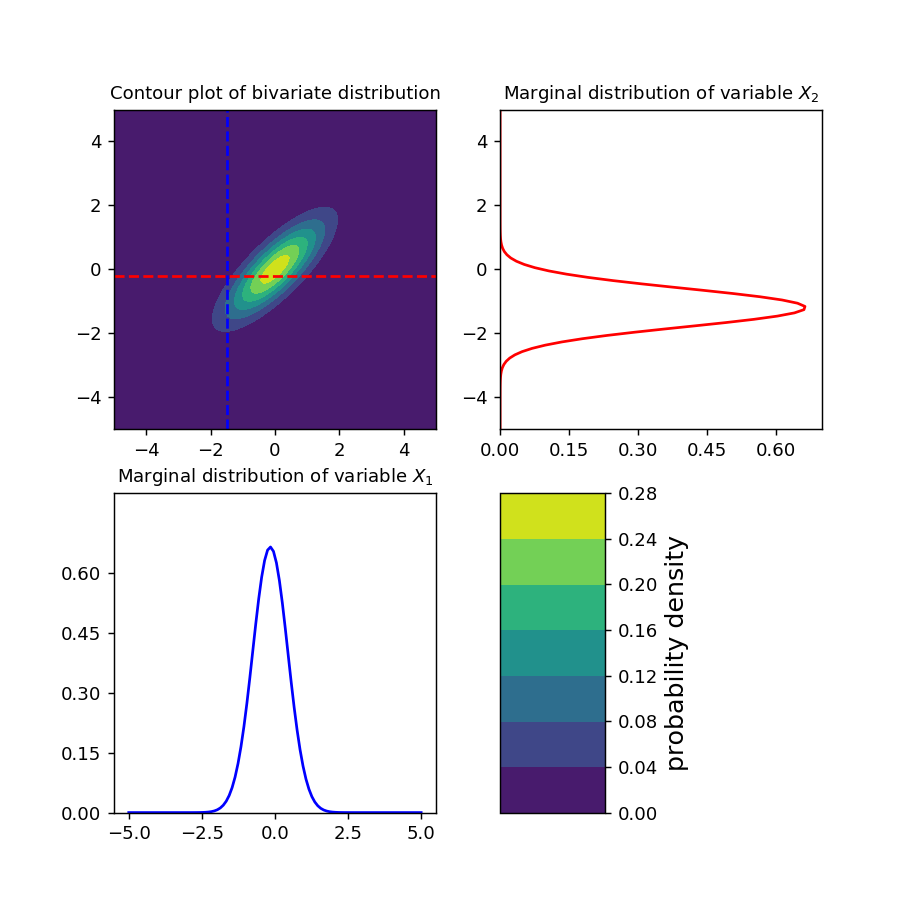

In [7]:
# code modified from https://peterroelants.github.io/posts/multivariate-normal-primer/

fig,axes = plt.subplots(2, 2, figsize=(7, 7))

#axs[0,0] top left; contour plot showing where bivariate distribution is sliced when we are given X
cp = axes[0,0].contourf(X2_lin, X1_lin, Z)
axes[0,0].set_xlim(-5,5)
axes[0,0].set_ylim(-5,5)
axes[0,0].plot([-5, 5], [X2_condition, X2_condition], 'r--')
axes[0,0].plot([X1_condition, X1_condition], [-5, 5], 'b--')
axes[0,0].set_title("Contour plot of bivariate distribution", fontsize=10)

#axs[0,1] top right; conditional distribution of X2 given X1
# (X1 slices through the bivariate distribution at the blue line, giving the red conditional distribution of X2)
p1 = normal_distribution(X2_lin, mean_X2givenX1, cov_X2givenX1)
axes[0,1].plot(p1, X2_lin, color="red")
axes[0,1].set_xticks(np.linspace(0,0.6,5))
axes[0,1].set_xlim(0, 0.7)
axes[0,1].set_ylim(-5, 5)
axes[0,1].set_title("Marginal distribution of variable $X_2$", fontsize=10)

#axs[1,0] bottom left; conditional distribution of X1 given X2
# (X2 slices through the bivariate distribution at the red line, giving the blue conditional distribution of X1)
p = normal_distribution(X1_lin, mean_X1givenX2, cov_X1givenX2) 
axes[1,0].plot(X1_lin, p, color="blue")
axes[1,0].set_ylim(-5, 5)
axes[1,0].set_ylim(0, 0.8)
axes[1,0].set_yticks(np.linspace(0,0.6,5))
axes[1,0].set_title("Marginal distribution of variable $X_1$", fontsize=10)

#axs[1,1]
axes[1,1].set_visible(False)
divider = make_axes_locatable(axes[1,1])
cax = divider.append_axes('left', size='50%', pad=0.05)
cbar = fig.colorbar(cp, cax=cax)
cbar.ax.set_ylabel('probability density', fontsize=14)

plt.show()

Take $X_1$ given $X_2$ as an example. We assigned a value of 0.2 to $X_2$, so we are given $X_2$. Imagine we cut through the three-dimensional plot of the bivariate distribution at $X_2$ = 0.2 (dashed red line on contour plot). Where the cut happens, a new normal distribution that is the conditional distribution of $X_1$ is formed (blue graph at the bottom left). The formed blue conditional distribution (which is also a normal distribution) has the conditional mean and conditional covariance matrix (in this case only a variance because the conditional distribution is univariate). The process is the same for higher dimensions, applying the respective formulas to give the conditional mean vector and conditional covariance matrix.

## References

1. https://en.wikipedia.org/wiki/Multivariate_normal_distribution

1. https://en.wikipedia.org/wiki/Joint_probability_distribution#Density_function_or_mass_function

1. https://scipython.com/blog/visualizing-the-bivariate-gaussian-distribution/

1. https://peterroelants.github.io/posts/multivariate-normal-primer/

1. https://online.stat.psu.edu/stat505/lesson/6/6.1

1. https://stats.stackexchange.com/questions/30588/deriving-the-conditional-distributions-of-a-multivariate-normal-distribution

1. http://www.math.uwaterloo.ca/~hwolkowi//matrixcookbook.pdf

1. http://www.gaussianprocess.org/gpml/chapters/RW.pdf